# Bee Stuff

https://youtu.be/x2jDLDaxM74

In [9]:
from BleFinley import *
import pymc as pm
from matplotlib import pyplot as plt
import arviz as az
import numpy as np

tx_c = Transmitter('c', -1.450168, 53.368359, 122.0 + 1.5)
range_trial = BleLogStatic("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/7.log", tx_c, -1.449617, 53.370239, 111.2)
# range_trial = BleLogStatic("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/2.log", tx_c, -1.449851, 53.368798, 124.3)

BleLog | tx: c, no.packets: 1533, time: 86.140s
BleLogStatic | angle offset: -9.507


In [5]:
def rss_diff_at_gamma(ble_log :BleLog, gamma :float, packet_gap = 1) -> list[int]:
    rss_at_gamma = ble_log.all_rss_at_gamma(gamma)
    rss_differences = []

    for x in range(len(rss_at_gamma) - packet_gap):
        rss_differences.append(rss_at_gamma[x] - rss_at_gamma[x + packet_gap])

    return rss_differences

diffs = []

for degree in range(-15, 15):
    diffs.extend(rss_diff_at_gamma(range_trial, degree))

## Split Distribution using Estimated Guesses

Assuming the distribution of RSS differences is formed of two distributions (one with a very small standard deviation and one that's high), separate the data into two sections by finding the standard deviation from the entire dataset and splitting it by being more or less than 1 std away from the mean.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

/home/finley/Git/BLEanalysis/.venv1/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 11 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,0.13,0.10,-0.06,0.33,0.0,0.0,51004.81,36616.32,1.0
std_posterior,3.57,0.07,3.43,3.71,0.0,0.0,52097.25,38116.96,1.0


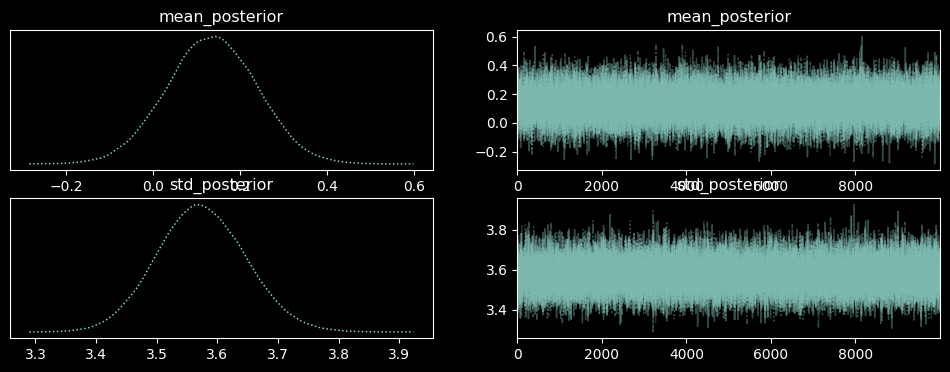

In [17]:
# use all data to get normal PD
bee_model = pm.Model()

with bee_model:
    mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    std_prior = pm.HalfNormal("std_posterior", sigma=2)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs)

    trace = pm.sample(10_000, chains=5)

az.plot_trace(trace, combined=True)
summary_all = az.summary(trace, round_to=2)
display(summary_all)

### Narrow Portion

Isolate the portion around the mean and get the parameters of that normal distribution

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 12 seconds.
There were 117 divergences after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,-0.04,3.0,-5.59,5.75,0.02,0.01,22756.23,25123.43,1.0
std_posterior,1.59,1.2,0.00,3.76,0.01,0.01,18278.62,14041.39,1.0


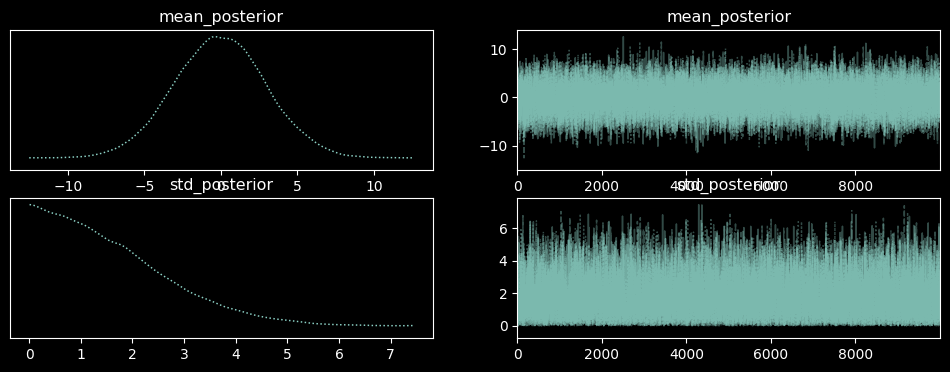

In [18]:
# filter out all "wide" values
diffs_narrow = []
std_all = summary_all.loc["std_posterior", "mean"]

for diff in diffs:
    if std_all <= diff <= std_all:
        diffs_narrow.append(diff)

bee_model = pm.Model()

with bee_model:
    # mean_prior = pm.Uniform("mean_posterior", lower=-5, upper=5)
    mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    std_prior = pm.HalfNormal("std_posterior", sigma=2)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_narrow)

    trace = pm.sample(10_000, chains=5)

az.plot_trace(trace, combined=True)
summary_narrow = az.summary(trace, round_to=2)
display(summary_narrow)

### Wide distribution


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 10 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,0.23,0.24,-0.23,0.68,0.0,0.0,50411.40,37245.39,1.0
std_posterior,5.42,0.17,5.10,5.74,0.0,0.0,50253.24,35646.63,1.0


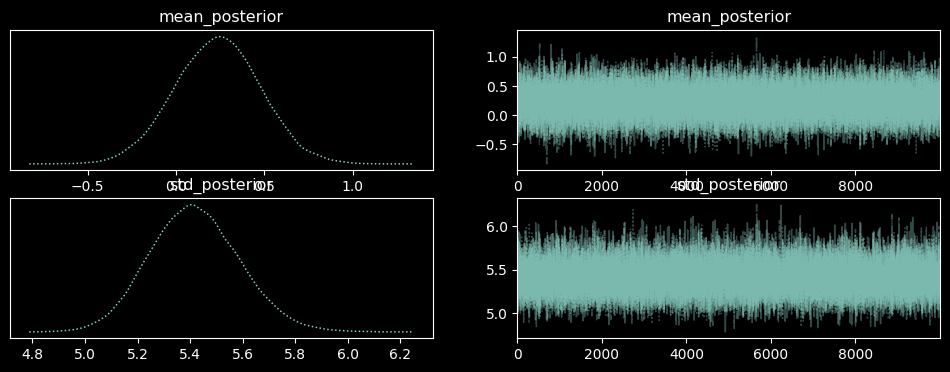

In [19]:
diffs_wide = []

# filter out all "narrow" values
for diff in diffs:
    if diff <= -std_all or diff >= std_all:
        diffs_wide.append(diff)

# add padding values from -5 to 6
num_border_vals = diffs_wide.count(-7)
for pad in range(-6, 7):
    diffs_wide.extend([pad] * num_border_vals)

bee_wide_model = pm.Model()

with bee_wide_model:
    mean_prior = pm.Uniform("mean_posterior", lower=-5, upper=5)
    # mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    # std_prior = pm.HalfNormal("std_posterior", sigma=2)
    std_prior = pm.Uniform("std_posterior", lower=-17, upper=17)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_wide)

    trace_wide = pm.sample(10_000, chains=5)

az.plot_trace(trace_wide, combined=True)
summary_wide = az.summary(trace_wide, round_to=2)
display(summary_wide)

### Combined Distribution

Final model of RSS differences, combining all findings from above cells.

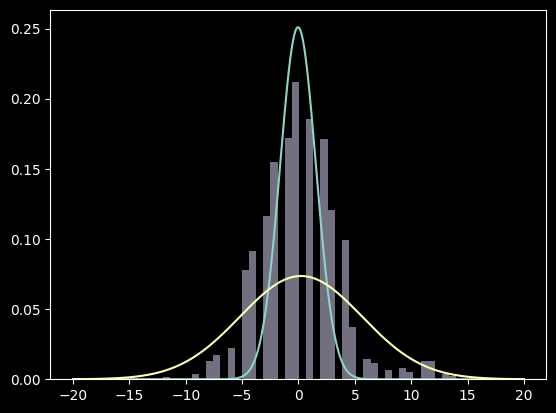

In [20]:
from scipy.stats import norm

x_axis = np.linspace(-20, 20, 1000)

y_narrow = norm.pdf(x_axis, summary_narrow.loc["mean_posterior", "mean"], summary_narrow.loc["std_posterior", "mean"])
y_yellow = norm.pdf(x_axis, summary_wide.loc["mean_posterior", "mean"], summary_wide.loc["std_posterior", "mean"])

plt.plot(x_axis, y_narrow)
plt.plot(x_axis, y_yellow)
plt.hist(diffs, bins=41, alpha=0.6, density=True)
plt.show()

## K-Means Clustering

Use K-Means clustering to separate the data points into two distributions and then get the parmeters of those distributions

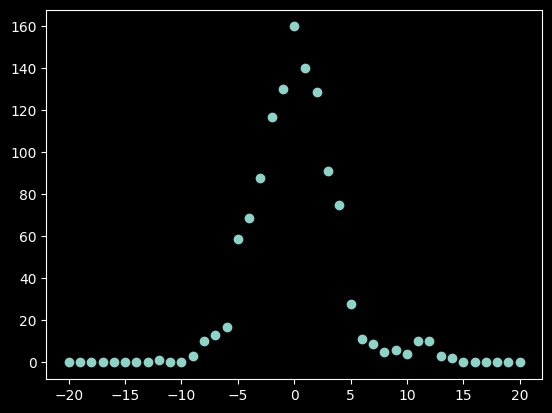

In [11]:
# diffs has rss diffs for +-15 degrees

freq_diff = [0] * 41 # [20] is diff of 0
rss = [-20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

for diff in diffs:
    try:
        freq_diff[diff + 20] += 1
    except:
        pass

plt.scatter(rss, freq_diff)

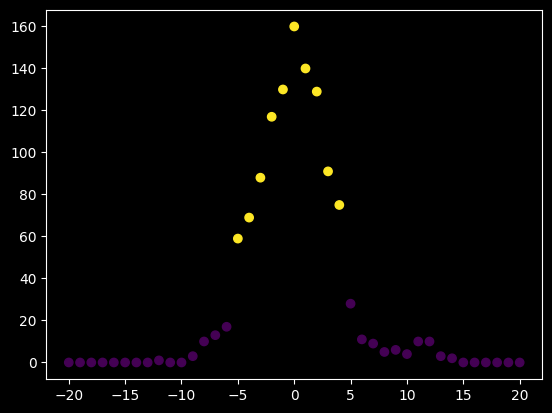

In [12]:
from sklearn.cluster import KMeans

data = list(zip(rss, freq_diff))

kmeans = KMeans(n_clusters=2)
kmeans.fit(np.array(freq_diff).reshape(-1,1))

plt.scatter(rss, freq_diff, c=kmeans.labels_)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 9 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,0.05,0.06,-0.07,0.17,0.0,0.0,48776.31,37300.45,1.0
std_posterior,1.83,0.04,1.75,1.92,0.0,0.0,51753.47,37144.71,1.0


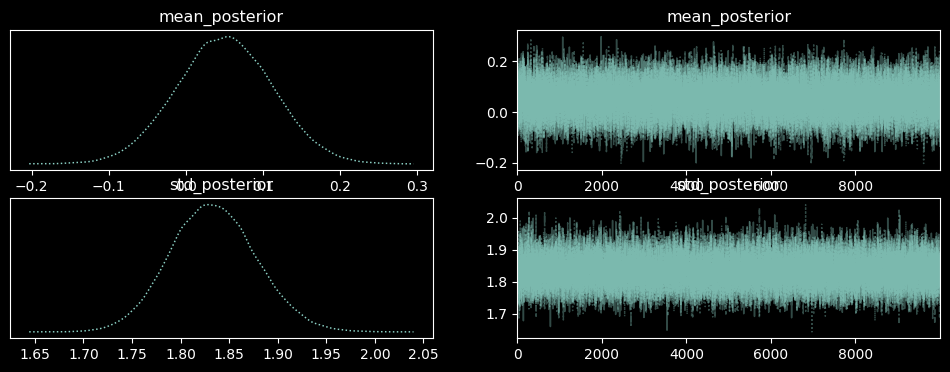

In [13]:
# rss values in pink: -3 to 4

diffs_pink = []
std_all = summary_narrow.loc["std_posterior", "mean"]

# filter out all "narrow" values
for diff in diffs:
    if -3 <= diff <= 3:
        diffs_pink.append(diff)

bee_wide_pink = pm.Model()

with bee_wide_pink:
    mean_prior = pm.Uniform("mean_posterior", lower=-3, upper=3)
    # mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    # std_prior = pm.HalfNormal("std_posterior", sigma=2)
    std_prior = pm.Uniform("std_posterior", lower=-5, upper=5)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_pink)

    trace_pink = pm.sample(10_000, chains=5)

az.plot_trace(trace_pink, combined=True)
summary_pink = az.summary(trace_pink, round_to=2)
display(summary_pink)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (5 chains in 3 jobs)
NUTS: [mean_posterior, std_posterior]


Output()

Sampling 5 chains for 1_000 tune and 10_000 draw iterations (5_000 + 50_000 draws total) took 9 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mean_posterior,0.35,0.33,-0.28,0.97,0.0,0.0,51664.10,35896.80,1.0
std_posterior,6.09,0.24,5.66,6.55,0.0,0.0,51609.06,35362.57,1.0


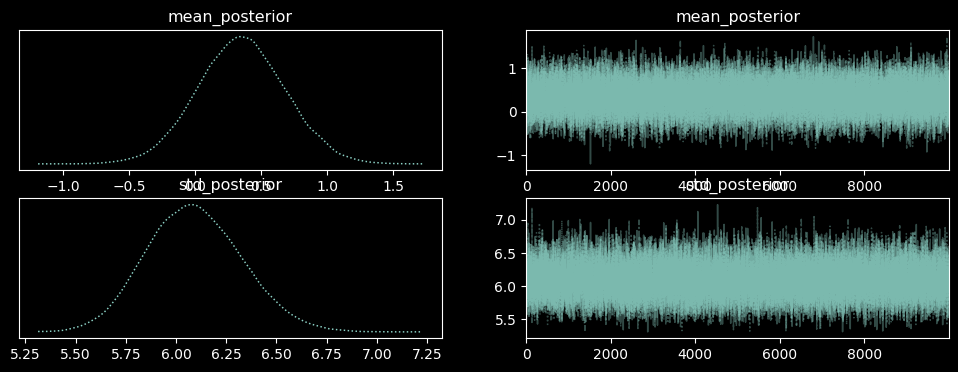

In [14]:
# rss values in yellow:  less than -3 or over 4

diffs_pink = []
std_all = summary_narrow.loc["std_posterior", "mean"]

# filter out all "narrow" values
for diff in diffs:
    if diff < -3 or diff > 3:
        diffs_pink.append(diff)

bee_wide_pink = pm.Model()

with bee_wide_pink:
    mean_prior = pm.Uniform("mean_posterior", lower=-10, upper=10)
    # mean_prior = pm.Normal("mean_posterior", mu=0, sigma=3)
    # std_prior = pm.HalfNormal("std_posterior", sigma=2)
    std_prior = pm.Uniform("std_posterior", lower=-17, upper=17)

    likelihood = pm.Normal("obs", mu=mean_prior, sigma=std_prior, observed=diffs_pink)

    trace_yellow = pm.sample(10_000, chains=5)

az.plot_trace(trace_yellow, combined=True)
summary_yellow = az.summary(trace_yellow, round_to=2)
display(summary_yellow)

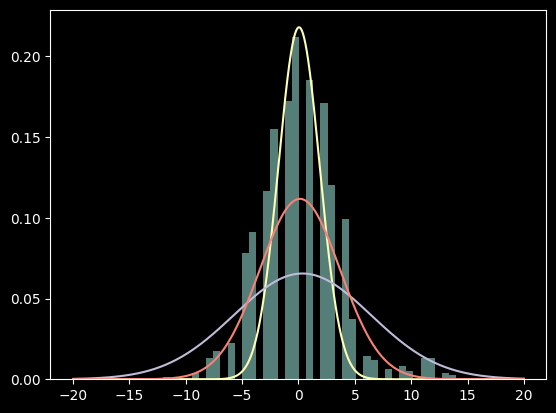

In [21]:
plt.hist(diffs, bins=41, alpha=0.6, density=True)

y_pink = norm.pdf(x_axis, summary_pink.loc["mean_posterior", "mean"], summary_pink.loc["std_posterior", "mean"])
y_yellow = norm.pdf(x_axis, summary_yellow.loc["mean_posterior", "mean"], summary_yellow.loc["std_posterior", "mean"])

plt.plot(x_axis, y_pink)
plt.plot(x_axis, y_yellow)

# normal over all diffs
all_norm = norm.pdf(x_axis, summary_all.loc["mean_posterior", "mean"], summary_all.loc["std_posterior", "mean"])
plt.plot(x_axis, all_norm)

plt.show()